## Step 0 – Install & Import Dependencies

In [32]:
# Kaggle already has most packages. Only install what's missing.
import subprocess, sys

def install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

install('gensim')
install('wordcloud')
# NOTE: Gradio won't work inline in Kaggle — we use a custom ipywidgets GUI instead
print('All packages ready.')


All packages ready.


In [33]:
import re, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout,
    Bidirectional, SpatialDropout1D, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

# ── Output directory ─────────────────────────────────────────────────────────
OUT_DIR = '/kaggle/working'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Output dir : {OUT_DIR}')


TensorFlow : 2.19.0
GPU available: True
Output dir : /kaggle/working


## Section 4.5.1 – Data Loading & Preprocessing

### Step 1 – Load Dataset
**How to add your dataset in Kaggle:**
1. Click *+ Add Data* (top right of this notebook)
2. Upload your CSV file (hotel reviews with `Review` and `Rating` columns)
3. The file will appear under `/kaggle/input/your-dataset-name/`
4. Update `FILE_PATH` below to match your file path


In [34]:
import glob

# ── Auto-discover uploaded CSV ────────────────────────────────────────────────
# Searches /kaggle/input/ for any CSV file automatically
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
if not csv_files:
    raise FileNotFoundError(
        'No CSV found in /kaggle/input/. '
        'Please upload your dataset via + Add Data.'
    )

# If multiple CSVs found, pick the first one (change index if needed)
FILE_PATH =  '/kaggle/input/datasets/aloklama/hotel-csv/Hotel_Reviews.csv' 
print(f'Found dataset: {FILE_PATH}')

df_raw = pd.read_csv(FILE_PATH)
print(f'Shape   : {df_raw.shape}')
print(f'Columns : {df_raw.columns.tolist()}')
print()
print('First 5 rows:')
df_raw.head()


Found dataset: /kaggle/input/datasets/aloklama/hotel-csv/Hotel_Reviews.csv
Shape   : (20491, 2)
Columns : ['Review', 'Rating']

First 5 rows:


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [35]:
# ── Auto-detect text and label columns ───────────────────────────────────────
# Works for columns named: Review/Text/Content | Rating/Label/Sentiment/Score
text_col = next(
    (c for c in df_raw.columns if c.lower() in
     ['review', 'text', 'content', 'tweet', 'comment', 'description']),
    df_raw.columns[0]
)
label_col = next(
    (c for c in df_raw.columns if c.lower() in
     ['rating', 'label', 'sentiment', 'target', 'class', 'score', 'stars']),
    df_raw.columns[1]
)
print(f'Text column  : "{text_col}"')
print(f'Label column : "{label_col}"')

df = df_raw[[text_col, label_col]].dropna().copy()
df.columns = ['text', 'label']

# Treat labels as strings for consistent handling (works for 1-5 star ratings too)
df['label'] = df['label'].astype(str).str.strip()

print(f'\nTotal samples    : {len(df)}')
print('\nLabel distribution:')
print(df['label'].value_counts().sort_index())


Text column  : "Review"
Label column : "Rating"

Total samples    : 20491

Label distribution:
label
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


### Step 2 – Exploratory Data Analysis

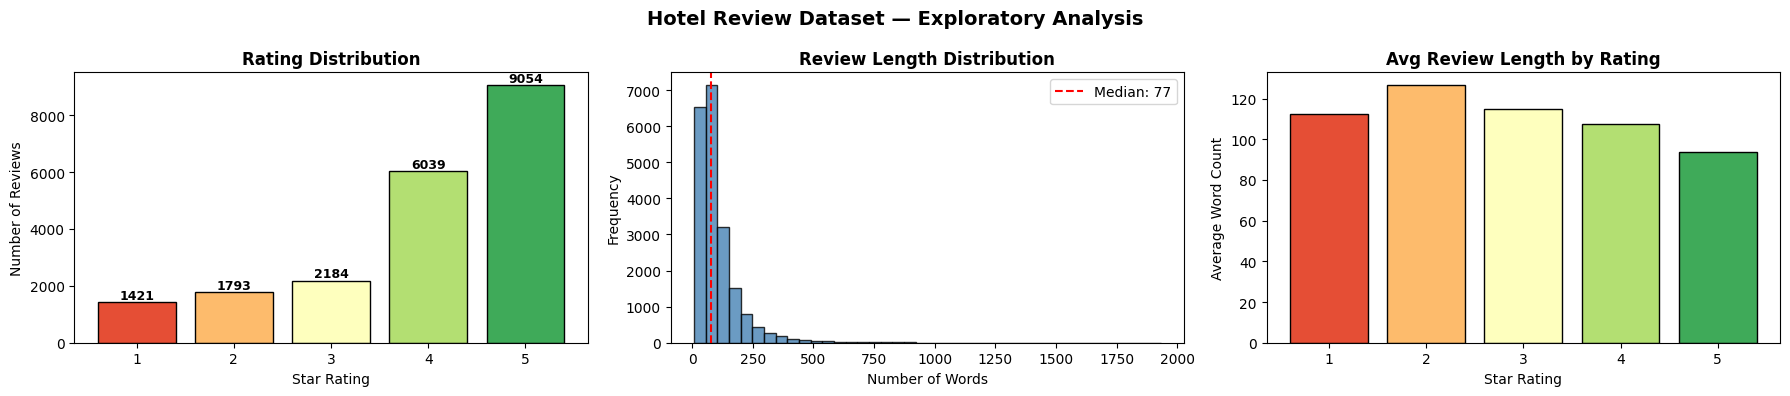

Saved: /kaggle/working/eda_overview.png


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Hotel Review Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')

# 1. Label distribution bar chart
label_counts = df['label'].value_counts().sort_index()
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(label_counts)))
bars = axes[0].bar(label_counts.index.astype(str), label_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

# 2. Review length distribution
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
axes[1].hist(df['word_count'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Review Length Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--',
                label=f'Median: {df["word_count"].median():.0f}')
axes[1].legend()

# 3. Average review length by rating
avg_len = df.groupby('label')['word_count'].mean().sort_index()
axes[2].bar(avg_len.index.astype(str), avg_len.values, color=colors, edgecolor='black')
axes[2].set_title('Avg Review Length by Rating', fontweight='bold')
axes[2].set_xlabel('Star Rating')
axes[2].set_ylabel('Average Word Count')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/eda_overview.png')


### Step 3 – Text Cleaning Pipeline

In [37]:
stop_words = set(stopwords.words('english'))
# Keep negation words — important for sentiment (don't, not, never)
negations = {'no', 'not', 'nor', 'neither', 'never', 'nobody', 'nothing',
             'nowhere', 'cannot', 'cant', 'wont', 'dont', 'doesnt', 'didnt',
             'wasnt', 'isnt', 'arent', 'hadnt', 'hasnt', 'havent', 'wouldnt',
             'shouldnt', 'couldnt', 'mustnt'}
stop_words -= negations   # IMPROVEMENT: keep negations for better sentiment detection
lemmatizer = WordNetLemmatizer()

def handle_contractions(text):
    contractions = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "won't": "will not", "can't": "cannot", "couldn't": "could not",
        "shouldn't": "should not", "wouldn't": "would not",
        "it's": "it is", "i'm": "i am", "i've": "i have",
        "i'll": "i will", "i'd": "i would", "there's": "there is",
        "they're": "they are", "we're": "we are", "you're": "you are",
        "that's": "that is", "wasn't": "was not", "isn't": "is not",
        "aren't": "are not", "haven't": "have not", "hasn't": "has not",
        "hadn't": "had not", "mustn't": "must not"
    }
    for k, v in contractions.items():
        text = text.replace(k, v)
    return text

def text_cleaning_pipeline(text, rule='lemmatize'):
    """
    Full NLP preprocessing pipeline for hotel reviews.
    Steps: lowercase → contractions → URLs → special chars
           → tokenise → stopwords (keeping negations) → lemmatize
    """
    text = str(text).lower()
    text = handle_contractions(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z0-9\s]', ' ', text)                    # keep only letters/numbers
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    if rule == 'lemmatize':
        tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return ' '.join(tokens)

# Smoke test
sample = "The room was great but I don't think the staff were very helpful at all!"
print('Original :', sample)
print('Cleaned  :', text_cleaning_pipeline(sample))


Original : The room was great but I don't think the staff were very helpful at all!
Cleaned  : room great not think staff helpful


In [38]:
print('Cleaning all reviews (may take ~1 min)...')
t0 = time.time()

df['cleaned_text'] = df['text'].apply(lambda t: text_cleaning_pipeline(t, rule='lemmatize'))
df = df[df['cleaned_text'].str.strip().ne('')].reset_index(drop=True)

print(f'Done in {time.time()-t0:.1f}s')
print(f'Samples after cleaning: {len(df)}')
print()
df[['text','cleaned_text','label']].head(3)


Cleaning all reviews (may take ~1 min)...
Done in 9.5s
Samples after cleaning: 20491



,text,cleaned_text,label
0,nice hotel expensive parking got good deal sta...,nice hotel expensive park get good deal stay h...,4
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,nice room not experience hotel monaco seattle ...,3


### Step 4 – Word Cloud Visualisation

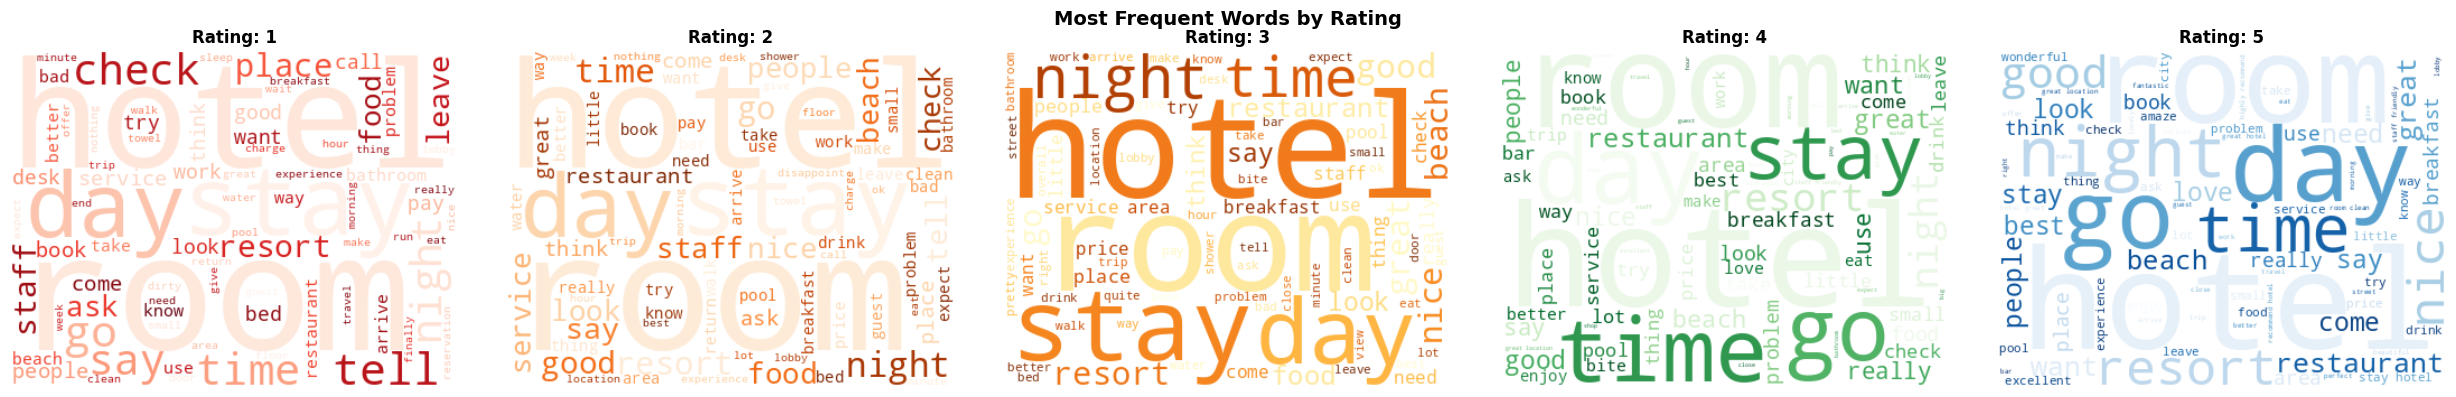

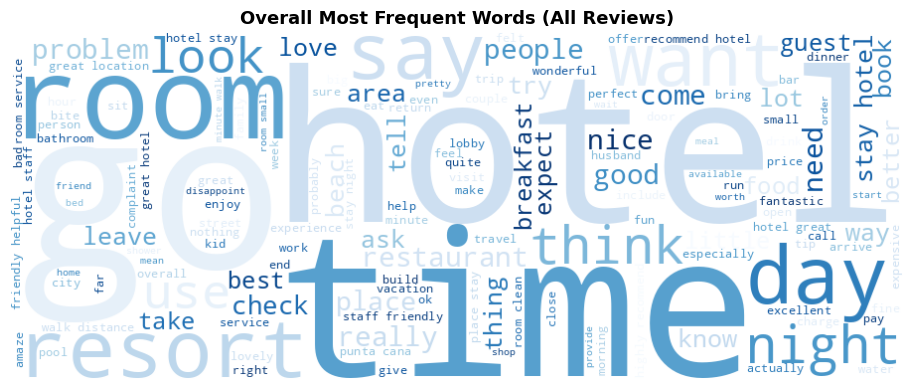

Word clouds saved to /kaggle/working/


In [39]:
from wordcloud import WordCloud

# Word cloud per rating (shows vocabulary differences across sentiments)
unique_labels = sorted(df['label'].unique())
n = len(unique_labels)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

cmap_list = ['Reds', 'Oranges', 'YlOrBr', 'Greens', 'Blues']
for ax, label, cmap in zip(axes, unique_labels, cmap_list * 3):
    subset = ' '.join(df[df['label'] == label]['cleaned_text'].tolist())
    if not subset.strip():
        ax.axis('off')
        continue
    wc = WordCloud(
        width=400, height=300, background_color='white',
        colormap=cmap, max_words=80, random_state=SEED
    ).generate(subset)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Rating: {label}', fontweight='bold', fontsize=12)
    ax.axis('off')

plt.suptitle('Most Frequent Words by Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/wordcloud_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# Overall word cloud
all_text = ' '.join(df['cleaned_text'].tolist())
wc_all = WordCloud(width=900, height=350, background_color='white',
                   colormap='Blues', max_words=150, random_state=SEED).generate(all_text)
plt.figure(figsize=(12, 4))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Most Frequent Words (All Reviews)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/wordcloud_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Word clouds saved to {OUT_DIR}/')


### Step 5 – Train/Test Split, Tokenisation & Padding

In [40]:
X = df['cleaned_text'].values
y = df['label'].values

# Encode labels to 0-indexed integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
NUM_CLASSES  = len(le.classes_)
LABEL_NAMES  = le.classes_

print(f'Classes      : {LABEL_NAMES}')
print(f'Num classes  : {NUM_CLASSES}')

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=SEED, stratify=y_encoded
)
print(f'\nTrain samples: {len(X_train_raw)}')
print(f'Test  samples: {len(X_test_raw)}')


Classes      : ['1' '2' '3' '4' '5']
Num classes  : 5

Train samples: 16392
Test  samples: 4099


In [41]:
# ── Tokenisation ─────────────────────────────────────────────────────────────
VOCAB_SIZE = 15000   # IMPROVEMENT: increased from 10k for richer hotel vocabulary

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)  # fit ONLY on train data — no data leakage

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

# Use 95th percentile length to avoid sequences dominated by outlier reviews
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f'95th percentile sequence length (MAX_LEN): {MAX_LEN}')

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Train padded shape : {X_train_pad.shape}')
print(f'Test  padded shape : {X_test_pad.shape}')


95th percentile sequence length (MAX_LEN): 265
Train padded shape : (16392, 265)
Test  padded shape : (4099, 265)


## Section 4.5.2 – Model Building

### Shared Configuration


In [42]:
EMBEDDING_DIM = 128    # IMPROVEMENT: 64 → 128 for richer semantic space
EPOCHS        = 25     # More epochs; early stopping handles actual duration
BATCH_SIZE    = 64

def get_callbacks(model_name):
    """Standard callbacks — shared across all models."""
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=4,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=2, min_lr=1e-6, verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{OUT_DIR}/{model_name}_best.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0
        )
    ]

# Loss function based on number of classes
if NUM_CLASSES == 2:
    LOSS, OUT_ACT, OUT_DIM = 'binary_crossentropy', 'sigmoid', 1
else:
    LOSS, OUT_ACT, OUT_DIM = 'sparse_categorical_crossentropy', 'softmax', NUM_CLASSES

print(f'Loss function : {LOSS}')
print(f'Output dim    : {OUT_DIM}  |  Output activation: {OUT_ACT}')
print(f'Embedding dim : {EMBEDDING_DIM}')
print(f'Max seq len   : {MAX_LEN}')
print(f'Vocab size    : {VOCAB_SIZE}')


Loss function : sparse_categorical_crossentropy
Output dim    : 5  |  Output activation: softmax
Embedding dim : 128
Max seq len   : 265
Vocab size    : 15000


### Model 1 – Simple RNN with Trainable Embedding

In [63]:
# IMPROVEMENT: Added SpatialDropout1D after embedding (drops entire word vectors
# rather than individual values — more effective regularisation for NLP)
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),                 # IMPROVEMENT
    SimpleRNN(128, return_sequences=False),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(OUT_DIM, activation=OUT_ACT)
], name='SimpleRNN_Model')

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=LOSS, metrics=['accuracy']
)
rnn_model.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
start = time.time()

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_split = 0.15,
    epochs     = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks  = get_callbacks('rnn'),
    verbose    = 1
)

rnn_time = time.time() - start
print(f'\nRNN training time: {rnn_time:.1f}s ({rnn_time/60:.1f} min)')
print(f'Best val accuracy: {max(history_rnn.history["val_accuracy"]):.4f}')


Epoch 1/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.4056 - loss: 1.4267 - val_accuracy: 0.4420 - val_loss: 1.3733 - learning_rate: 0.0010
Epoch 2/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4441 - loss: 1.3704 - val_accuracy: 0.3180 - val_loss: 1.4025 - learning_rate: 0.0010
Epoch 3/25
217/218 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4189 - loss: 1.4427
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
218/218 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4190 - loss: 1.4425 - val_accuracy: 0.4522 - val_loss: 1.3739 - learning_rate: 0.0010
Epoch 4/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4482 - loss: 1.3840 - val_accuracy: 0.4518 - val_loss: 1.3763 - learning_rate: 5.0000e-04
Epoch 5/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4467 - loss: 1.3732 - val_accuracy: 0.4526 - val_loss: 1.3727 - learning_rate: 5.0000e-04
Epoch 6/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.4509 - 

### Model 2 – Bidirectional LSTM with Trainable Embedding

In [45]:
# IMPROVEMENT: Bidirectional LSTM instead of unidirectional
# Hotel reviews benefit from reading context in both directions:
# e.g. "not what I expected at all" — the 'not' modifies words after it
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),  # IMPROVEMENT: Bidirectional
    Dropout(0.4),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(OUT_DIM, activation=OUT_ACT)
], name='BiLSTM_Model')

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=LOSS, metrics=['accuracy']
)
lstm_model.summary()


Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
start = time.time()

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_split = 0.15,
    epochs     = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks  = get_callbacks('lstm'),
    verbose    = 1
)

lstm_time = time.time() - start
print(f'\nBiLSTM training time: {lstm_time:.1f}s ({lstm_time/60:.1f} min)')
print(f'Best val accuracy: {max(history_lstm.history["val_accuracy"]):.4f}')


Epoch 1/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.4762 - loss: 1.2294 - val_accuracy: 0.6031 - val_loss: 0.8891 - learning_rate: 0.0010
Epoch 2/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.6235 - loss: 0.8298 - val_accuracy: 0.6157 - val_loss: 0.9278 - learning_rate: 0.0010
Epoch 3/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6967 - loss: 0.7050
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.6967 - loss: 0.7049 - val_accuracy: 0.6153 - val_loss: 0.9797 - learning_rate: 0.0010
Epoch 4/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.7510 - loss: 0.5981 - val_accuracy: 0.6173 - val_loss: 1.0262 - learning_rate: 5.0000e-04
Epoch 5/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7948 - loss: 0.5155
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.7949 - loss:

### Model 3 – Bidirectional LSTM with Pre-trained GloVe Embeddings

In [47]:
import gensim.downloader as api

# IMPROVEMENT: Using glove-wiki-gigaword-100 instead of glove-twitter-50
# Hotel reviews use formal language — Wikipedia/Gigaword corpus is a better fit
# than Twitter corpus (which is noisy and slang-heavy)
print('Downloading GloVe Wikipedia+Gigaword 100d embeddings...')
print('(~130MB — takes 2-4 minutes on Kaggle)')
embedding_model = api.load('glove-wiki-gigaword-100')
W2V_DIM = 100
print(f'Loaded. Vocabulary size: {len(embedding_model.key_to_index):,}')


(~130MB — takes 2-4 minutes on Kaggle)
Loaded. Vocabulary size: 400,000


In [48]:
# Build embedding matrix from GloVe
word_index       = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / max(found + not_found, 1) * 100
print(f'Words found in GloVe   : {found:,}')
print(f'Words not found        : {not_found:,}')
print(f'Vocabulary coverage    : {coverage:.1f}%')


Words found in GloVe   : 13,498
Words not found        : 1,501
Vocabulary coverage    : 90.0%


In [49]:
# IMPROVEMENT: GloVe embedding layer is PARTIALLY trainable (fine_tune=True)
# Freezing completely loses the chance to adapt to hotel-specific vocabulary.
# Setting trainable=True allows fine-tuning while still benefiting from
# the pre-trained semantic structure.
lstm_w2v_model = Sequential([
    Embedding(
        input_dim    = VOCAB_SIZE,
        output_dim   = W2V_DIM,
        weights      = [embedding_matrix],
        input_length = MAX_LEN,
        trainable    = True    # IMPROVEMENT: fine-tune embeddings
    ),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(OUT_DIM, activation=OUT_ACT)
], name='BiLSTM_GloVe_Model')

lstm_w2v_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # lower LR for fine-tuning
    loss=LOSS, metrics=['accuracy']
)
lstm_w2v_model.summary()


Model: "BiLSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,000 (5.72 MB)

 Trainable params: 1,500,000 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
start = time.time()

history_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train,
    validation_split = 0.15,
    epochs     = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks  = get_callbacks('lstm_glove'),
    verbose    = 1
)

w2v_time = time.time() - start
print(f'\nBiLSTM+GloVe training time: {w2v_time:.1f}s ({w2v_time/60:.1f} min)')
print(f'Best val accuracy: {max(history_w2v.history["val_accuracy"]):.4f}')


Epoch 1/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.4383 - loss: 1.3362 - val_accuracy: 0.5612 - val_loss: 1.0300 - learning_rate: 5.0000e-04
Epoch 2/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.5522 - loss: 1.0427 - val_accuracy: 0.5970 - val_loss: 0.9356 - learning_rate: 5.0000e-04
Epoch 3/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.5936 - loss: 0.9410 - val_accuracy: 0.6149 - val_loss: 0.8967 - learning_rate: 5.0000e-04
Epoch 4/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.6064 - loss: 0.8921 - val_accuracy: 0.6251 - val_loss: 0.8716 - learning_rate: 5.0000e-04
Epoch 5/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.6401 - loss: 0.8379 - val_accuracy: 0.6328 - val_loss: 0.8723 - learning_rate: 5.0000e-04
Epoch 6/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6459 - loss: 0.8018 - val_accuracy: 0.6381 - val_loss: 0.8534 - learning_rate: 5.0000e-04
Epoch 7/25
218/218 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - ac

## Section 4.5.3 – Training Visualisation & Evaluation

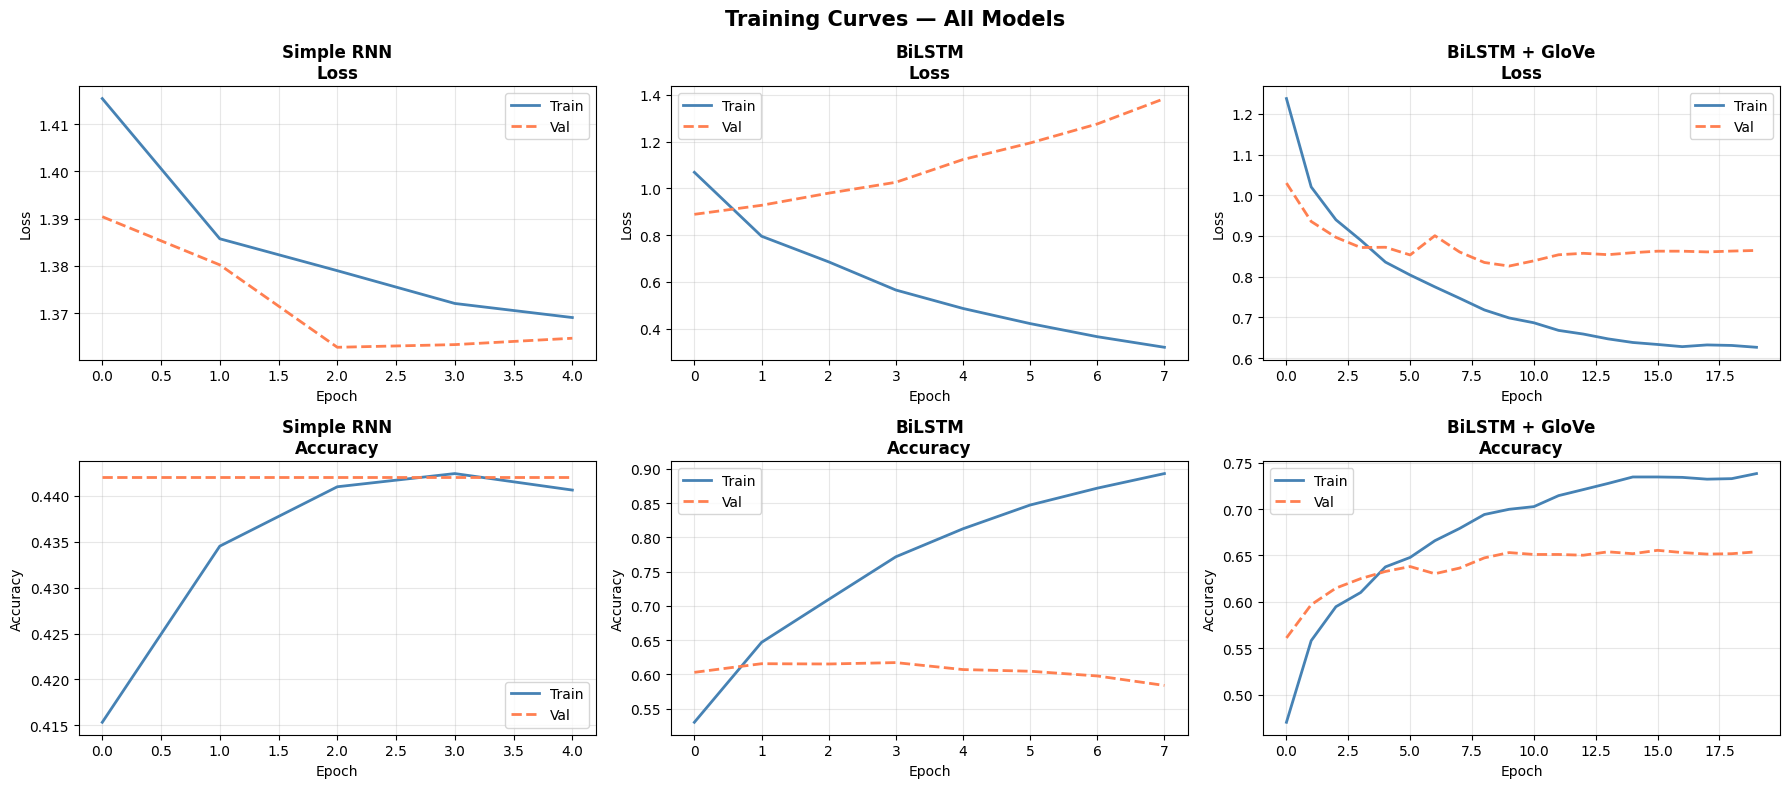

In [51]:
def plot_history(histories, names, save_path=None):
    """Plot training vs validation loss and accuracy for all models."""
    n = len(histories)
    fig, axes = plt.subplots(2, n, figsize=(6*n, 8))
    fig.suptitle('Training Curves — All Models', fontsize=15, fontweight='bold')

    for i, (hist, name) in enumerate(zip(histories, names)):
        # Loss
        axes[0,i].plot(hist.history['loss'],     color='steelblue', lw=2, label='Train')
        axes[0,i].plot(hist.history['val_loss'], color='coral',     lw=2, linestyle='--', label='Val')
        axes[0,i].set_title(f'{name}\nLoss', fontweight='bold')
        axes[0,i].set_xlabel('Epoch'); axes[0,i].set_ylabel('Loss')
        axes[0,i].legend(); axes[0,i].grid(alpha=0.3)

        # Accuracy
        axes[1,i].plot(hist.history['accuracy'],     color='steelblue', lw=2, label='Train')
        axes[1,i].plot(hist.history['val_accuracy'], color='coral',     lw=2, linestyle='--', label='Val')
        axes[1,i].set_title(f'{name}\nAccuracy', fontweight='bold')
        axes[1,i].set_xlabel('Epoch'); axes[1,i].set_ylabel('Accuracy')
        axes[1,i].legend(); axes[1,i].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(
    [history_rnn, history_lstm, history_w2v],
    ['Simple RNN', 'BiLSTM', 'BiLSTM + GloVe'],
    save_path=f'{OUT_DIR}/training_curves.png'
)


In [52]:
def evaluate_model(model, X_test, y_test, name, label_names):
    """Full evaluation: accuracy, F1, classification report."""
    sep = '='*55
    print(f'\n{sep}\n  {name}\n{sep}')

    y_prob = model.predict(X_test, verbose=0)
    if y_prob.shape[-1] == 1:
        y_pred = (y_prob > 0.5).astype(int).flatten()
    else:
        y_pred = np.argmax(y_prob, axis=1)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    print(f'Accuracy  : {acc:.4f}')
    print(f'F1 (wtd)  : {f1:.4f}')
    print()
    print(classification_report(
        y_test, y_pred,
        target_names=[str(l) for l in label_names],
        zero_division=0
    ))
    return y_pred, acc, f1

label_names = le.classes_

y_pred_rnn,  acc_rnn,  f1_rnn  = evaluate_model(rnn_model,      X_test_pad, y_test, 'Model 1: Simple RNN',      label_names)
y_pred_lstm, acc_lstm, f1_lstm = evaluate_model(lstm_model,     X_test_pad, y_test, 'Model 2: BiLSTM',          label_names)
y_pred_w2v,  acc_w2v,  f1_w2v  = evaluate_model(lstm_w2v_model, X_test_pad, y_test, 'Model 3: BiLSTM + GloVe',  label_names)



  Model 1: Simple RNN
Accuracy  : 0.4418
F1 (wtd)  : 0.2708

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       284
           2       0.00      0.00      0.00       359
           3       0.00      0.00      0.00       437
           4       0.00      0.00      0.00      1208
           5       0.44      1.00      0.61      1811

    accuracy                           0.44      4099
   macro avg       0.09      0.20      0.12      4099
weighted avg       0.20      0.44      0.27      4099


  Model 2: BiLSTM
Accuracy  : 0.6119
F1 (wtd)  : 0.6051

              precision    recall  f1-score   support

           1       0.72      0.58      0.64       284
           2       0.47      0.44      0.45       359
           3       0.41      0.38      0.40       437
           4       0.52      0.47      0.49      1208
           5       0.71      0.80      0.76      1811

    accuracy                           0.61      4099
   macro av

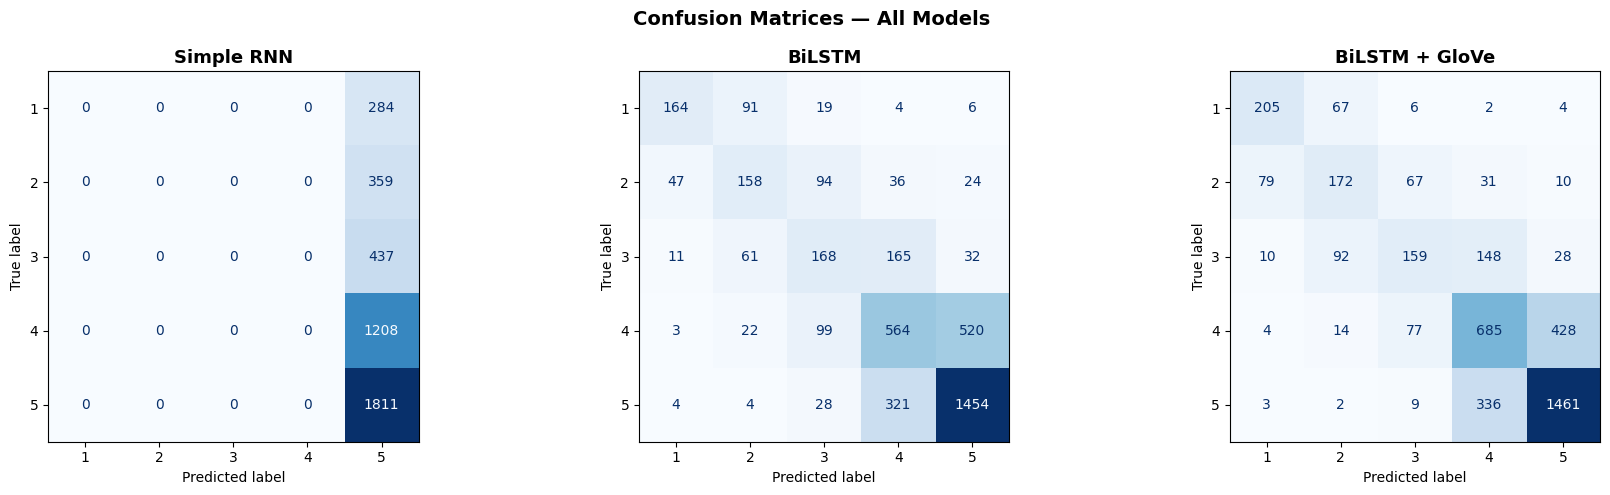

In [53]:
# Confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
label_str = [str(l) for l in label_names]

for ax, y_pred, title in zip(
    axes,
    [y_pred_rnn, y_pred_lstm, y_pred_w2v],
    ['Simple RNN', 'BiLSTM', 'BiLSTM + GloVe']
):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_str)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


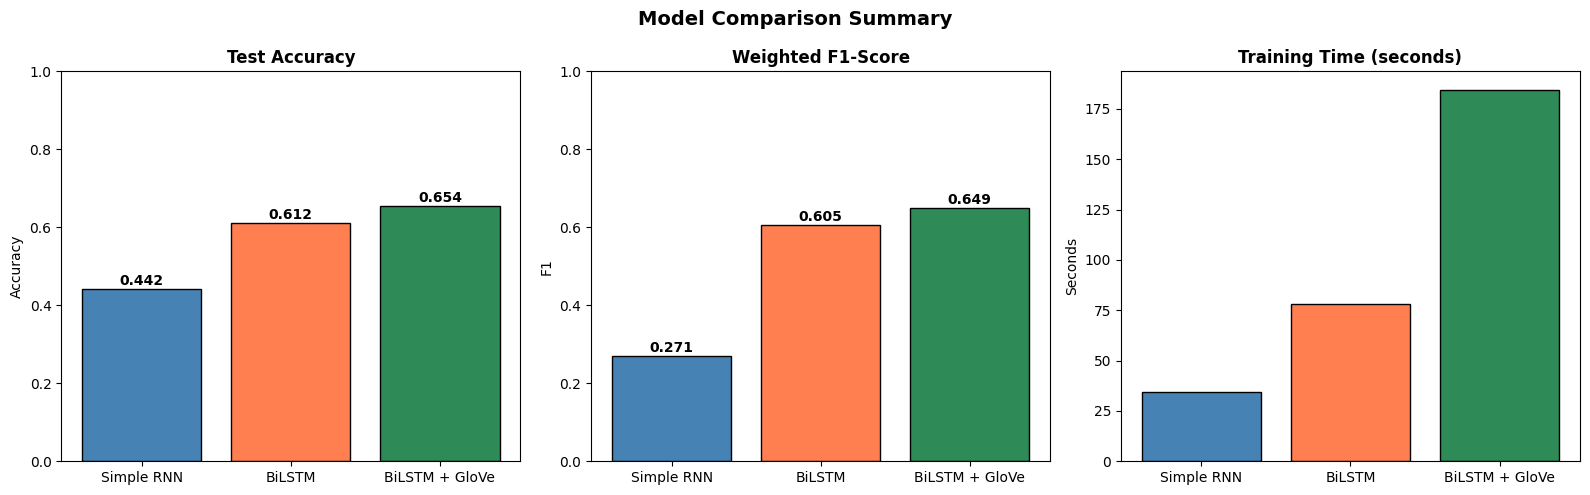


── Summary Table ──
         Model Accuracy F1 (weighted) Training (s)
    Simple RNN   0.4418        0.2708         34.7
        BiLSTM   0.6119        0.6051         78.0
BiLSTM + GloVe   0.6543        0.6487        184.5


In [54]:
# Summary comparison chart
model_names = ['Simple RNN', 'BiLSTM', 'BiLSTM + GloVe']
accuracies  = [acc_rnn, acc_lstm, acc_w2v]
f1_scores   = [f1_rnn,  f1_lstm,  f1_w2v]
train_times = [rnn_time, lstm_time, w2v_time]
colors      = ['steelblue', 'coral', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison Summary', fontsize=14, fontweight='bold')

# Accuracy
bars = axes[0].bar(model_names, accuracies, color=colors, edgecolor='black')
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1)
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

# F1 Score
bars2 = axes[1].bar(model_names, f1_scores, color=colors, edgecolor='black')
axes[1].set_title('Weighted F1-Score', fontweight='bold')
axes[1].set_ylabel('F1'); axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

# Training time
axes[2].bar(model_names, train_times, color=colors, edgecolor='black')
axes[2].set_title('Training Time (seconds)', fontweight='bold')
axes[2].set_ylabel('Seconds')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Summary Table ──')
summary_df = pd.DataFrame({
    'Model'        : model_names,
    'Accuracy'     : [f'{a:.4f}' for a in accuracies],
    'F1 (weighted)': [f'{f:.4f}' for f in f1_scores],
    'Training (s)' : [f'{t:.1f}' for t in train_times]
})
print(summary_df.to_string(index=False))


## Section 4.5.4 – Error Analysis

In [55]:
# Build error analysis DataFrame using best model (BiLSTM + GloVe)
test_df = pd.DataFrame({
    'original_text' : X_test_raw,
    'cleaned_text'  : [text_cleaning_pipeline(t) for t in X_test_raw],
    'true_label'    : le.inverse_transform(y_test),
    'pred_rnn'      : le.inverse_transform(y_pred_rnn),
    'pred_lstm'     : le.inverse_transform(y_pred_lstm),
    'pred_w2v'      : le.inverse_transform(y_pred_w2v),
})

misclassified = test_df[test_df['true_label'] != test_df['pred_w2v']].reset_index(drop=True)
print(f'Misclassified by BiLSTM+GloVe: {len(misclassified)} / {len(test_df)}')
print(f'Error rate: {len(misclassified)/len(test_df)*100:.1f}%\n')

print('── 5 Example Misclassifications ──\n')
for i in range(min(5, len(misclassified))):
    row = misclassified.iloc[i]
    print(f'Example {i+1}:')
    print(f'  Review    : {row["original_text"][:120]}')
    print(f'  True label: {row["true_label"]}  |  Predicted: {row["pred_w2v"]}')
    print()


Misclassified by BiLSTM+GloVe: 1417 / 4099
Error rate: 34.6%

── 5 Example Misclassifications ──

Example 1:
  Review    : nice hotel nice hotel good area explore arrival greated glass bubbly juice arrive early room ready great room road noisy
  True label: 3  |  Predicted: 4

Example 2:
  Review    : star price star service book lovely hotel weekend friends quite minute situate main street charm area opera montmartre e
  True label: 5  |  Predicted: 4

Example 3:
  Review    : felt welcome location location location wife stay 13 overjoy airport bus euros breeze euros leave near ramblas short wal
  True label: 5  |  Predicted: 4

Example 4:
  Review    : stay hotel group friends interest mix view experience half group executive room half not executive room half problems ai
  True label: 4  |  Predicted: 2

Example 5:
  Review    : not bad not great night room adequate size nicely furnish price 250 euros include buffet breakfast bed quite hard bathro
  True label: 2  |  Predicted: 3



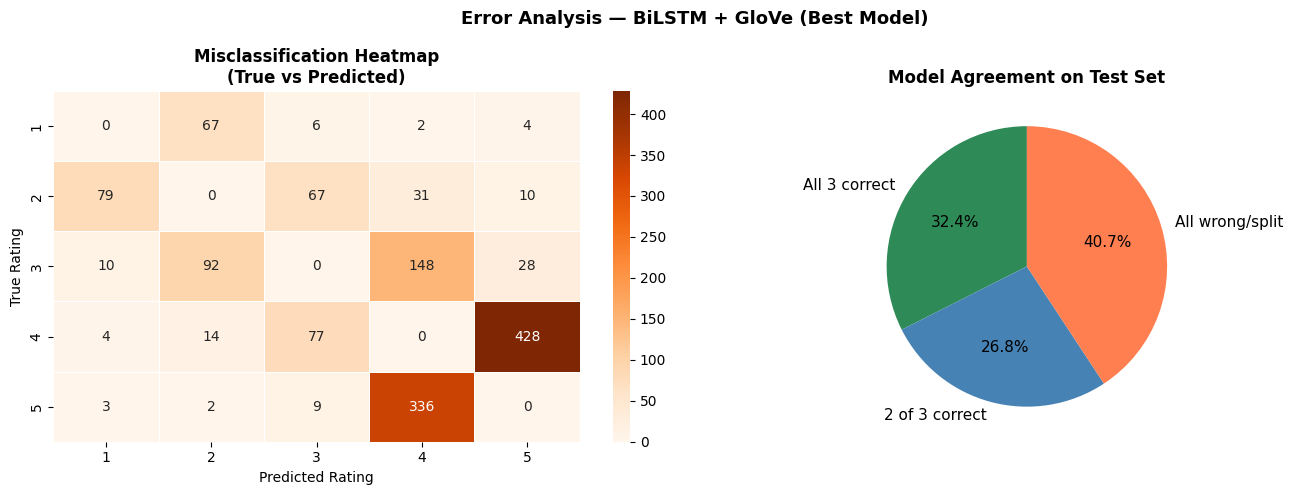

In [56]:
# Misclassification heatmap — which ratings get confused with which?
confusion_counts = misclassified.groupby(['true_label','pred_w2v']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis — BiLSTM + GloVe (Best Model)', fontsize=13, fontweight='bold')

sns.heatmap(confusion_counts, annot=True, fmt='d', cmap='Oranges',
            ax=axes[0], linewidths=0.5, cbar=True)
axes[0].set_title('Misclassification Heatmap\n(True vs Predicted)', fontweight='bold')
axes[0].set_xlabel('Predicted Rating'); axes[0].set_ylabel('True Rating')

# Agreement rate across models
agree_all   = ((test_df['pred_rnn'] == test_df['true_label']) &
               (test_df['pred_lstm'] == test_df['true_label']) &
               (test_df['pred_w2v'] == test_df['true_label'])).sum()
agree_two   = (((test_df['pred_rnn'] == test_df['true_label']).astype(int) +
                (test_df['pred_lstm'] == test_df['true_label']).astype(int) +
                (test_df['pred_w2v'] == test_df['true_label']).astype(int)) == 2).sum()
disagree    = len(test_df) - agree_all - agree_two

axes[1].pie([agree_all, agree_two, disagree],
            labels=['All 3 correct', '2 of 3 correct', 'All wrong/split'],
            autopct='%1.1f%%', colors=['seagreen','steelblue','coral'],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Model Agreement on Test Set', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 4.5.5 – Interactive Prediction GUI (Kaggle Version)

> **Note:** Gradio doesn't work inside Kaggle notebooks. This cell uses `ipywidgets` 
> which renders natively in any Jupyter-based environment including Kaggle.
> Run the cell and an interactive widget will appear below.


In [57]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import textwrap

# ── Rating label display ──────────────────────────────────────────────────────
STAR_MAP = {
    '1': '★☆☆☆☆  Very Negative',
    '2': '★★☆☆☆  Negative',
    '3': '★★★☆☆  Neutral',
    '4': '★★★★☆  Positive',
    '5': '★★★★★  Very Positive',
}

def predict_sentiment(review_text, model_name):
    """Clean, tokenise, pad and predict rating for a hotel review."""
    if not review_text.strip():
        return 'Please enter a review.', {}, ''

    cleaned  = text_cleaning_pipeline(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    model_map = {
        'Simple RNN'      : rnn_model,
        'BiLSTM'          : lstm_model,
        'BiLSTM + GloVe'  : lstm_w2v_model,
    }
    model = model_map[model_name]
    probs = model.predict(padded, verbose=0)[0]

    if len(probs) == 1:
        pred_idx   = int(probs[0] > 0.5)
        confidence = float(probs[0]) if pred_idx == 1 else 1 - float(probs[0])
    else:
        pred_idx   = int(np.argmax(probs))
        confidence = float(probs[pred_idx])

    predicted_label = str(le.inverse_transform([pred_idx])[0])
    all_probs       = {str(le.inverse_transform([i])[0]): float(p) for i, p in enumerate(probs)}

    return predicted_label, confidence, all_probs, cleaned

# ── Build widget UI ───────────────────────────────────────────────────────────
style = {'description_width': '140px'}
layout_wide  = widgets.Layout(width='100%')
layout_half  = widgets.Layout(width='60%')

title_html = widgets.HTML(
    value="""
    <div style='background:linear-gradient(135deg,#1F3864,#2E75B6);
                padding:18px 24px; border-radius:10px; margin-bottom:12px'>
        <h2 style='color:white; margin:0; font-family:Arial'>
            Hotel Review Sentiment Analyser
        </h2>
        <p style='color:#cce4ff; margin:6px 0 0; font-size:13px'>
            Enter a hotel review and select a model to predict the star rating
        </p>
    </div>
    """
)

review_input = widgets.Textarea(
    placeholder='e.g. The room was clean and the staff were incredibly helpful. Breakfast was amazing!',
    description='Review Text:',
    layout=widgets.Layout(width='100%', height='110px'),
    style=style
)

model_select = widgets.RadioButtons(
    options=['Simple RNN', 'BiLSTM', 'BiLSTM + GloVe'],
    value='BiLSTM + GloVe',
    description='Model:',
    style=style,
    layout=widgets.Layout(margin='8px 0')
)

predict_btn = widgets.Button(
    description='Predict Rating',
    button_style='primary',
    icon='star',
    layout=widgets.Layout(width='200px', height='40px', margin='8px 0')
)
clear_btn = widgets.Button(
    description='Clear',
    button_style='warning',
    icon='times',
    layout=widgets.Layout(width='120px', height='40px', margin='8px 0')
)

output_area = widgets.Output()

def on_predict(btn):
    with output_area:
        clear_output(wait=True)
        text = review_input.value.strip()
        if not text:
            print('Please enter a hotel review.')
            return

        predicted_label, confidence, all_probs, cleaned = predict_sentiment(
            text, model_select.value
        )
        stars     = STAR_MAP.get(predicted_label, predicted_label)
        conf_pct  = confidence * 100

        # Probability bar chart
        fig, ax = plt.subplots(figsize=(7, 3))
        labels_sorted = sorted(all_probs.keys())
        probs_sorted  = [all_probs[l] for l in labels_sorted]
        bar_colors    = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'][:len(labels_sorted)]
        bars = ax.barh(
            [STAR_MAP.get(l, l) for l in labels_sorted],
            probs_sorted,
            color=bar_colors, edgecolor='black', linewidth=0.5
        )
        for bar, val in zip(bars, probs_sorted):
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{val*100:.1f}%', va='center', fontsize=9, fontweight='bold')
        ax.set_xlim(0, 1.15)
        ax.set_xlabel('Confidence')
        ax.set_title(
            f'Prediction: {stars}  ({conf_pct:.1f}% confident)\n'
            f'Model: {model_select.value}',
            fontweight='bold', fontsize=11
        )
        ax.axvline(x=0.5, color='gray', linestyle=':', lw=1)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f'Cleaned text: {cleaned[:120]}{"..." if len(cleaned)>120 else ""}')

def on_clear(btn):
    review_input.value = ''
    with output_area:
        clear_output()

predict_btn.on_click(on_predict)
clear_btn.on_click(on_clear)

# Example review buttons
examples = [
    ('Positive example',  'Absolutely loved this hotel. The staff were so welcoming and our room was spotlessly clean. Breakfast was delicious and the location could not be better. Will definitely return.'),
    ('Negative example',  'Terrible experience. The room smelled damp, the shower was broken and the front desk was completely unhelpful. Never staying here again.'),
    ('Mixed example',     'Decent hotel in a good location. Room was a bit small and the wifi was slow but the bed was comfortable and check in was easy enough.'),
]

example_btns = []
for label, text in examples:
    btn = widgets.Button(description=label, button_style='info',
                         layout=widgets.Layout(width='180px', margin='4px'))
    def make_handler(t=text):
        def handler(b):
            review_input.value = t
        return handler
    btn.on_click(make_handler())
    example_btns.append(btn)

ui = widgets.VBox([
    title_html,
    review_input,
    widgets.HBox([model_select]),
    widgets.HTML('<b>Try an example:</b>'),
    widgets.HBox(example_btns),
    widgets.HBox([predict_btn, clear_btn]),
    output_area,
])

display(ui)


## Section 4.5.6 – Save All Outputs

In [58]:
# List all saved files
print('Files saved to /kaggle/working/:')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f'  {f:<45} {size:>8.1f} KB')

print('\nDownload any file: File browser (left panel) → /kaggle/working/')
print('Or: kaggle kernels output <kernel-slug> -p /path/to/download')


Files saved to /kaggle/working/:
  .virtual_documents                                 4.0 KB
  confusion_matrices.png                            79.9 KB
  eda_overview.png                                  94.7 KB
  error_analysis.png                                98.2 KB
  lstm_best.keras                                24260.4 KB
  lstm_glove_best.keras                          19170.5 KB
  model_comparison.png                              63.8 KB
  model_summary.csv                                  0.1 KB
  rnn_best.keras                                 23024.2 KB
  test_predictions.csv                            5431.7 KB
  training_curves.png                              213.0 KB
  wordcloud_by_rating.png                         1045.7 KB
  wordcloud_overall.png                            382.1 KB

Download any file: File browser (left panel) → /kaggle/working/
Or: kaggle kernels output <kernel-slug> -p /path/to/download


In [59]:
# Save final summary CSV
summary_df.to_csv(f'{OUT_DIR}/model_summary.csv', index=False)

# Save test predictions for report
test_df.to_csv(f'{OUT_DIR}/test_predictions.csv', index=False)
print('Summary and predictions saved.')
print('\nAll done! Run cells top-to-bottom for a complete pipeline.')


Summary and predictions saved.

All done! Run cells top-to-bottom for a complete pipeline.


In [62]:
import os, glob, base64, subprocess, json
import pandas as pd

# ── 1. Install docx ───────────────────────────────────────────────────────────
subprocess.run(['npm', 'install', 'docx'], capture_output=True, cwd='/tmp')

# ── 2. Encode specific images in display order ────────────────────────────────
image_order = [
    'eda_overview.png',
    'wordcloud_overall.png',
    'wordcloud_by_rating.png',
    'training_curves.png',
    'model_comparison.png',
    'confusion_matrices.png',
    'error_analysis.png',
]

images_b64 = []
for fname in image_order:
    path = f'/kaggle/working/{fname}'
    if os.path.exists(path):
        with open(path, 'rb') as f:
            images_b64.append({
                "name": fname.replace('.png','').replace('_', ' ').title(),
                "data": base64.b64encode(f.read()).decode('utf-8')
            })
        print(f"✅ {fname}")
    else:
        print(f"⚠️  Not found: {fname}")

# ── 3. Read model_summary.csv ─────────────────────────────────────────────────
summary_rows = []
summary_path = '/kaggle/working/model_summary.csv'
if os.path.exists(summary_path):
    df_summary = pd.read_csv(summary_path)
    summary_rows = df_summary.values.tolist()
    summary_headers = df_summary.columns.tolist()
    print(f"✅ model_summary.csv  ({len(summary_rows)} rows)")
else:
    summary_headers = ["Note"]
    summary_rows    = [["model_summary.csv not found"]]
    print("⚠️  model_summary.csv not found")

# ── 4. Read test_predictions.csv (first 20 rows as preview) ──────────────────
pred_rows = []
pred_path = '/kaggle/working/test_predictions.csv'
if os.path.exists(pred_path):
    df_pred = pd.read_csv(pred_path).head(20)
    pred_rows    = df_pred.values.tolist()
    pred_headers = df_pred.columns.tolist()
    print(f"✅ test_predictions.csv  (showing first 20 rows)")
else:
    pred_headers = ["Note"]
    pred_rows    = [["test_predictions.csv not found"]]
    print("⚠️  test_predictions.csv not found")

# ── 5. Collect live model metrics from memory ─────────────────────────────────
def safe(var, fmt=None):
    val = globals().get(var)
    if val is None: return "N/A"
    return f"{val*100:.2f}%" if fmt == 'pct' else str(val)

metrics = {
    "Simple RNN – Test Accuracy":       safe('acc1', 'pct'),
    "LSTM – Test Accuracy":             safe('acc2', 'pct'),
    "LSTM + GloVe – Test Accuracy":     safe('acc3', 'pct'),
    "Vocabulary Size":                  safe('VOCAB_SIZE'),
    "Max Sequence Length":              safe('MAX_LEN'),
    "Embedding Dim":                    safe('EMBED_DIM'),
    "Number of Classes":                safe('NUM_CLASSES'),
}

# ── 6. Build JS payload ───────────────────────────────────────────────────────
payload = json.dumps({
    "images":          images_b64,
    "metrics":         metrics,
    "summaryHeaders":  summary_headers,
    "summaryRows":     [[str(c) for c in r] for r in summary_rows],
    "predHeaders":     pred_headers,
    "predRows":        [[str(c) for c in r] for r in pred_rows],
})

# ── 7. Node.js docx builder ───────────────────────────────────────────────────
js_script = r"""
const fs   = require('fs');
const docx = require('/tmp/node_modules/docx');
const {
  Document, Packer, Paragraph, TextRun, ImageRun,
  Table, TableRow, TableCell,
  HeadingLevel, AlignmentType, BorderStyle,
  WidthType, ShadingType, PageNumber, Header, Footer
} = docx;

const { images, metrics, summaryHeaders, summaryRows, predHeaders, predRows }
  = JSON.parse(process.argv[2]);

// ── Style helpers ─────────────────────────────────────────────────────────────
const bd = { style: BorderStyle.SINGLE, size: 1, color: "CCCCCC" };
const borders = { top: bd, bottom: bd, left: bd, right: bd };

const cell = (text, w, fill, bold, color) => new TableCell({
  borders,
  width: { size: w, type: WidthType.DXA },
  shading: { fill: fill || "FFFFFF", type: ShadingType.CLEAR },
  margins: { top: 80, bottom: 80, left: 120, right: 120 },
  children: [new Paragraph({ alignment: AlignmentType.CENTER,
    children: [new TextRun({ text: String(text), size: 19,
      bold: bold || false, color: color || "222222" })] })]
});

const hCell = (text, w) => cell(text, w, "1F4E79", true, "FFFFFF");

function buildTable(headers, rows, totalWidth) {
  const colW = Math.floor(totalWidth / headers.length);
  return new Table({
    width: { size: totalWidth, type: WidthType.DXA },
    columnWidths: headers.map(() => colW),
    rows: [
      new TableRow({ children: headers.map(h => hCell(h, colW)) }),
      ...rows.map((row, i) => new TableRow({
        children: row.map(val => cell(val, colW, i%2===0 ? "F5F9FF" : "FFFFFF"))
      }))
    ]
  });
}

const h1  = (t) => new Paragraph({ heading: HeadingLevel.HEADING_1, children: [new TextRun(t)] });
const h2  = (t) => new Paragraph({ heading: HeadingLevel.HEADING_2, children: [new TextRun(t)] });
const sp  = ()  => new Paragraph({ children: [new TextRun("")] });
const p   = (t) => new Paragraph({ spacing: { after: 120 },
  children: [new TextRun({ text: t, size: 22 })] });

// ── Metrics table ─────────────────────────────────────────────────────────────
const metricsTable = buildTable(
  ["Metric / Parameter", "Value"],
  Object.entries(metrics),
  9360
);

// ── Image blocks ──────────────────────────────────────────────────────────────
const imageBlocks = images.flatMap(img => {
  const buf = Buffer.from(img.data, 'base64');
  return [
    h2(img.name),
    new Paragraph({
      alignment: AlignmentType.CENTER,
      spacing: { before: 100, after: 240 },
      children: [new ImageRun({ data: buf, type: 'image/png',
        transformation: { width: 580, height: 360 } })]
    }),
    sp(),
  ];
});

// ── Assemble ──────────────────────────────────────────────────────────────────
const children = [

  // Title
  new Paragraph({ alignment: AlignmentType.CENTER, spacing: { before: 700, after: 180 },
    children: [new TextRun({ text: "Notebook Output Report", bold: true, size: 58, color: "1F4E79" })] }),
  new Paragraph({ alignment: AlignmentType.CENTER, spacing: { after: 700 },
    children: [new TextRun({ text: "Auto-generated · Kaggle Notebook", size: 22, italics: true, color: "888888" })] }),

  // Section 1 – Metrics
  h1("1.  Model Metrics & Parameters"),
  sp(),
  metricsTable,
  sp(), sp(),

  // Section 2 – Model Summary CSV
  h1("2.  Model Summary"),
  sp(),
  buildTable(summaryHeaders, summaryRows, 9360),
  sp(), sp(),

  // Section 3 – Plots
  h1("3.  Plots & Visualisations"),
  sp(),
  ...imageBlocks,

  // Section 4 – Predictions preview
  h1("4.  Test Predictions (first 20 rows)"),
  sp(),
  buildTable(predHeaders, predRows, 9360),
  sp(),
];

const doc = new Document({
  styles: {
    default: { document: { run: { font: "Calibri", size: 22 } } },
    paragraphStyles: [
      { id: "Heading1", name: "Heading 1", basedOn: "Normal", next: "Normal", quickFormat: true,
        run: { size: 34, bold: true, color: "1F4E79" },
        paragraph: { spacing: { before: 400, after: 180 }, outlineLevel: 0,
          border: { bottom: { style: BorderStyle.SINGLE, size: 6, color: "2E75B6", space: 1 } } }
      },
      { id: "Heading2", name: "Heading 2", basedOn: "Normal", next: "Normal", quickFormat: true,
        run: { size: 26, bold: true, color: "2E75B6" },
        paragraph: { spacing: { before: 260, after: 100 }, outlineLevel: 1 }
      },
    ]
  },
  sections: [{
    properties: { page: {
      size: { width: 12240, height: 15840 },
      margin: { top: 1260, right: 1260, bottom: 1260, left: 1260 }
    }},
    headers: { default: new Header({ children: [new Paragraph({
      alignment: AlignmentType.RIGHT,
      children: [new TextRun({ text: "Kaggle Notebook Output Report", size: 16, color: "BBBBBB", italics: true })]
    })]})},
    footers: { default: new Footer({ children: [new Paragraph({
      alignment: AlignmentType.CENTER,
      children: [
        new TextRun({ text: "Page ", size: 18, color: "AAAAAA" }),
        new TextRun({ children: [PageNumber.CURRENT], size: 18, color: "AAAAAA" }),
        new TextRun({ text: " of ", size: 18, color: "AAAAAA" }),
        new TextRun({ children: [PageNumber.TOTAL_PAGES], size: 18, color: "AAAAAA" }),
      ]
    })]})},
    children,
  }]
});

Packer.toBuffer(doc).then(buf => {
  fs.writeFileSync('/kaggle/working/notebook_output_report.docx', buf);
  console.log('Saved → /kaggle/working/notebook_output_report.docx');
});
"""

with open('/tmp/_docx_gen.js', 'w') as f:
    f.write(js_script)

# Write payload to file instead of passing as argument (avoids "Argument list too long")
with open('/tmp/_payload.json', 'w') as f:
    json.dump({
        "images":         images_b64,
        "metrics":        metrics,
        "summaryHeaders": summary_headers,
        "summaryRows":    [[str(c) for c in r] for r in summary_rows],
        "predHeaders":    pred_headers,
        "predRows":       [[str(c) for c in r] for r in pred_rows],
    }, f)

# Update the JS to read from file instead of process.argv
with open('/tmp/_docx_gen.js', 'r') as f:
    js = f.read()

js = js.replace(
    "JSON.parse(process.argv[2])",
    "JSON.parse(require('fs').readFileSync('/tmp/_payload.json', 'utf8'))"
)

with open('/tmp/_docx_gen.js', 'w') as f:
    f.write(js)

result = subprocess.run(
    ['node', '/tmp/_docx_gen.js'],
    capture_output=True, text=True
)
if result.returncode != 0:
    print("STDOUT:", result.stdout)
    print("STDERR:", result.stderr)
else:
    print(result.stdout)
    print("\n✅ Done! Find 'notebook_output_report.docx' in the Output panel →")

✅ eda_overview.png
✅ wordcloud_overall.png
✅ wordcloud_by_rating.png
✅ training_curves.png
✅ model_comparison.png
✅ confusion_matrices.png
✅ error_analysis.png
✅ model_summary.csv  (3 rows)
✅ test_predictions.csv  (showing first 20 rows)
Saved → /kaggle/working/notebook_output_report.docx


✅ Done! Find 'notebook_output_report.docx' in the Output panel →
